In [ ]:
# Setup of all libraries needed and uploading the data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
train_test_split, GridSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

from sklearn.feature_extraction.text import TfidfVectorizer



In [ ]:
#import and inspect the data
data = pd.read_csv("Phishing_Email.csv")

print(f"Visualize Data:")
print(data.head(3))

Visualize Data:
   Unnamed: 0                                         Email Text  Email Type
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...  Safe Email
1           1  the other side of * galicismos * * galicismo *...  Safe Email
2           2  re : equistar deal tickets are you still avail...  Safe Email


In [ ]:
#print(data.head())
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB
None
         Unnamed: 0
count  18650.000000
mean    9325.154477
std     5384.327293
min        0.000000
25%     4662.250000
50%     9325.500000
75%    13987.750000
max    18650.000000


In [ ]:
# this code will help me find out how many categories is the email leveled as
columns = ["Email Type"]

for col in columns:
    classes = data[col].dropna().unique()

    print(f"\nColumn: {col}")
    print("Number of classes:", len(classes))
    print("Class names:")
    for c in classes:
        print("-", c)


Column: Email Type
Number of classes: 2
Class names:
- Safe Email
- Phishing Email


In [ ]:
#want to analyze what does an email looks like
data.values[1,1]

'the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is often considered to be a * barbarismo * . what would be the term which designates the opposite phenomenon , that is unlawful words of spanish origin which may have crept into french ? can someone provide examples ? thank you joseph m kozono < kozonoj @ gunet . georgetown . edu >'

In [ ]:
#will transform output to numeric value 0 or 1

data['safe_or_not'] = data['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

In [ ]:
# check for missing values in the Email text

data['Email Text'].isna().sum()

np.int64(16)

In [ ]:
# checks for non- strings  in the email text

(~data['Email Text'].apply(lambda x: isinstance(x, str))).sum()


np.int64(16)

In [ ]:
# cleaning the missing values and non-string values and putting everyting in lower case letters

data['Email Text'] = data['Email Text'].fillna('').astype(str)
data['Email Text'] = data['Email Text'].apply(lambda x: x.lower())



In [ ]:
#check email for phishing words manually, I tell computer which words or sgins to look for
#each word is converted into a number so we are keeping track of phishing word count

import re

def extract_features(text):

    return {
        'num_links': len(re.findall(r'http[s]?://', text)),
        'num_exclamations': text.count('!'),
        'num_uppercase_words': sum(1 for w in text.split() if w.isupper()),
        'has_urgent_words': int(any(word in text.lower() for word in ['urgent','immediately','action required', 'verify now', 'account suspended', 'act now'])),
        'has_money_words': int(any(word in text.lower() for word in ['bank','account','payment','invoice'])),
        'text_length': len(text),
    }

import pandas as pd

X_manual = pd.DataFrame([extract_features(t) for t in data['Email Text']])

print(X_manual.head(2)) # this give us an idea of what our data looks like now.


   num_links  num_exclamations  num_uppercase_words  has_urgent_words  \
0          0                 2                    0                 0   
1          0                 0                    0                 0   

   has_money_words  text_length  
0                0         1030  
1                0          479  


In [ ]:
# tfidf means term frequency  x inverse document frequency,
# which is the frequency to which words that appear in phishing email appear
#so we will be overlooking at all the prepositions in
#the english language and concentrating in the words that will help us
#distinguish between safe or phishing email

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,  # keep the 10000 most important words
    ngram_range=(1,3)  # for words like "click here now"
)

X_text = tfidf.fit_transform(data['Email Text'])

#print(X_text)

In [ ]:
# combining the two ways of search
# X_text is from tfidf and the X_manual is from idicating which words to look out for
from scipy.sparse import hstack

X_final = hstack([X_text, X_manual])
y = data['safe_or_not']

print(X_final.shape)
print(y.shape)  # 10000rom tfidf and 6 from x_manual

#print(X_final)
#print(y)

(18650, 10006)
(18650,)


Best parameters: {'n_estimators': 200, 'max_depth': None}


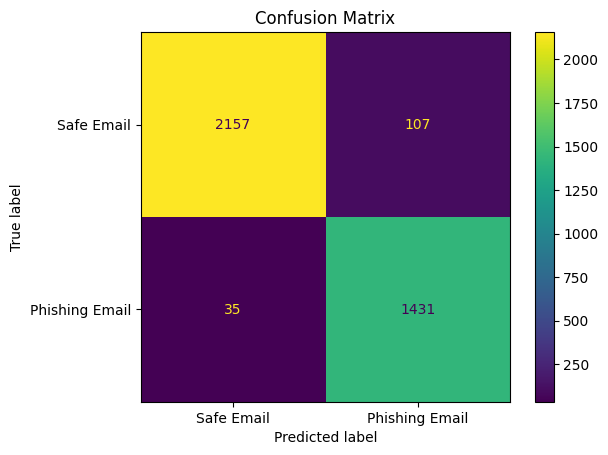

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2264
           1       0.93      0.98      0.95      1466

    accuracy                           0.96      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730



In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Split the data into training and testing sets


X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify = y
    )


# creating parameters
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
}

#using RandomForest and using CV so we don't overfit the data
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

y_pred = random_search.best_estimator_.predict(X_test)

print(f"Best parameters: {random_search.best_params_}")

#confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels = ['Safe Email', 'Phishing Email'])

plt.title('Confusion Matrix')
plt.show()

#report
print(classification_report(y_test, y_pred))